# Customer Churn Prediction: Analysis Notebook

This notebook walks through the full project: understanding the data, comparing models, explaining what drives churn, checking that the predicted probabilities can be trusted, and turning predictions into a cost-based retention decision.

**Data:** IBM Telco Customer Churn sample dataset (7,043 customers, 19 features, about 26.5% churned).

**Related:** the same steps are available as standalone scripts in this repository, and there is a [live demo app](https://customer-churn-prediction-hkedx4enxadhcr5uyxsmbl.streamlit.app/).

> Numbers may differ in the third decimal from the scripts' output because of library versions and random seeds. Dollar figures depend on illustrative assumptions (stated in section 7), not real company data.

**Contents**
1. Load and check the data
2. Exploratory analysis
3. Model comparison with cross-validation
4. What drives churn? (feature importance and SHAP)
5. Can we trust the probabilities? (calibration)
6. Limitations of the split used here
7. From predictions to money: who should we contact?
8. Conclusions

## 1. Load and check the data

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (GradientBoostingClassifier, HistGradientBoostingClassifier,
                              RandomForestClassifier)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss, log_loss,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RED, BLUE, GREEN, GRAY = "#d95f4b", "#4878a8", "#4a9a6b", "#8c8c8c"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": False})

In [2]:
CSV = Path("telco_clean.csv")
URL = ("https://raw.githubusercontent.com/AlaaNabil98/CodeClause_Customer_Churn_Rate_Analysis/"
       "main/WA_Fn-UseC_-Telco-Customer-Churn.csv")

if CSV.exists():
    df = pd.read_csv(CSV)
else:  # run standalone: download and clean the public dataset
    df = pd.read_csv(URL)
    df["Churn"] = (df["Churn"] == "Yes").astype(int)
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

TARGET, ID_COL = "Churn", "customerID"
print(f"{len(df):,} customers, {df.shape[1] - 2} features")
print(f"Churn rate: {df[TARGET].mean():.1%}")
df.head()

7,043 customers, 19 features
Churn rate: 26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [3]:
missing = df.isna().sum()
print("Columns with missing values:")
print(missing[missing > 0].to_string())
print("\nRows with missing TotalCharges all have tenure =",
      df.loc[df.TotalCharges.isna(), "tenure"].unique())

Columns with missing values:
TotalCharges    11

Rows with missing TotalCharges all have tenure = [0]


The only missing values are 11 `TotalCharges` entries, all belonging to brand-new customers with a tenure of 0 months (they have not been billed yet). The modelling pipeline fills these with the median.

The data is imbalanced (roughly 1 in 4 customers churned), so accuracy would be a misleading metric. I use ROC-AUC, PR-AUC, and top-decile lift instead.

## 2. Exploratory analysis

Which customer segments churn the most?

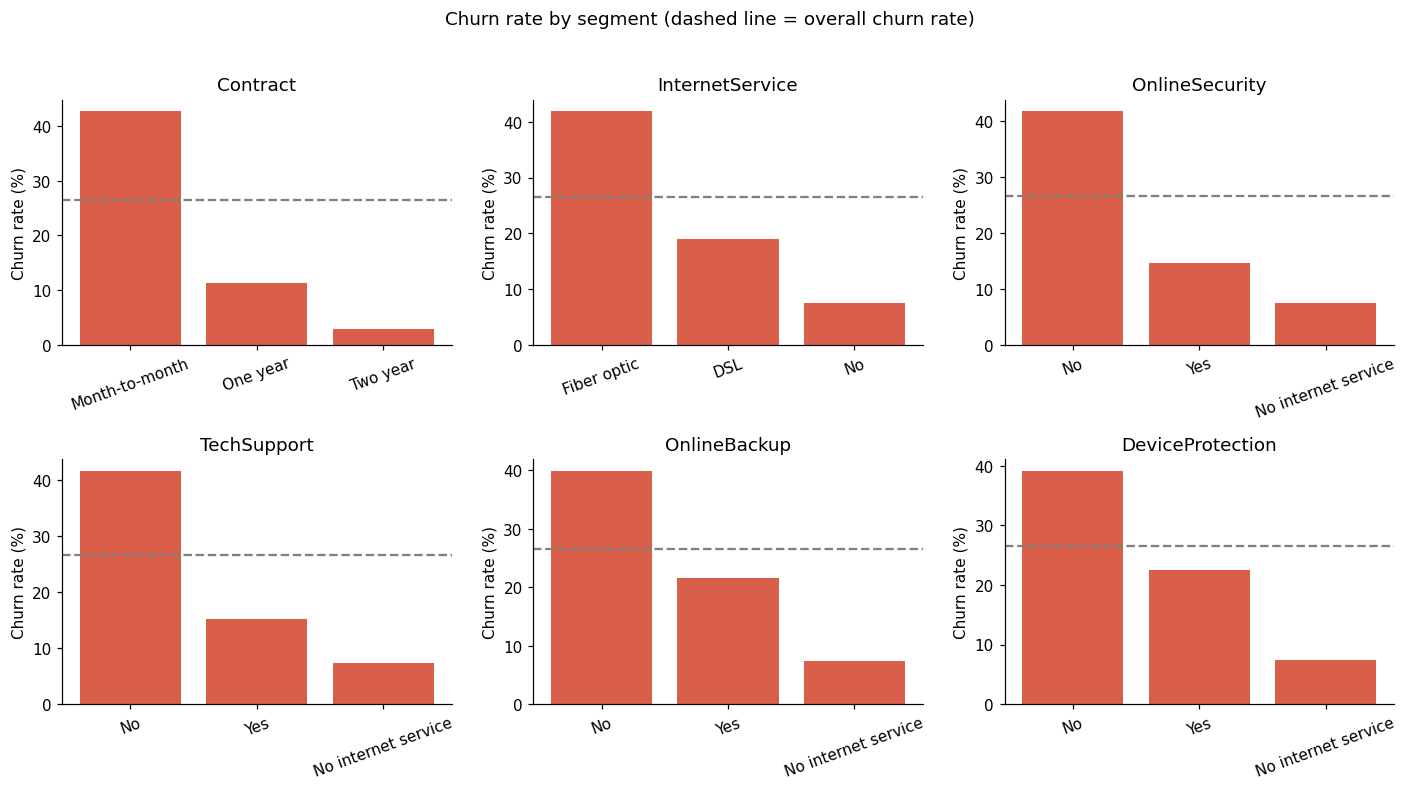

In [4]:
cats = [c for c in df.select_dtypes(exclude="number").columns
        if c != ID_COL and df[c].nunique() <= 6]
spread = {c: df.groupby(c)[TARGET].mean().agg(lambda s: s.max() - s.min()) for c in cats}
top = sorted(spread, key=spread.get, reverse=True)[:6]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, c in zip(axes.ravel(), top):
    rates = df.groupby(c)[TARGET].mean().sort_values(ascending=False) * 100
    ax.bar(rates.index.astype(str), rates.values, color=RED)
    ax.axhline(df[TARGET].mean() * 100, ls="--", color="gray")
    ax.set_title(c)
    ax.set_ylabel("Churn rate (%)")
    ax.tick_params(axis="x", rotation=20)
fig.suptitle("Churn rate by segment (dashed line = overall churn rate)", y=1.02)
fig.tight_layout()
plt.show()

The pattern is clear: customers on **month-to-month contracts**, with **fiber optic** internet, and **without online security or tech support** churn far more than average. Customers on two-year contracts almost never leave.

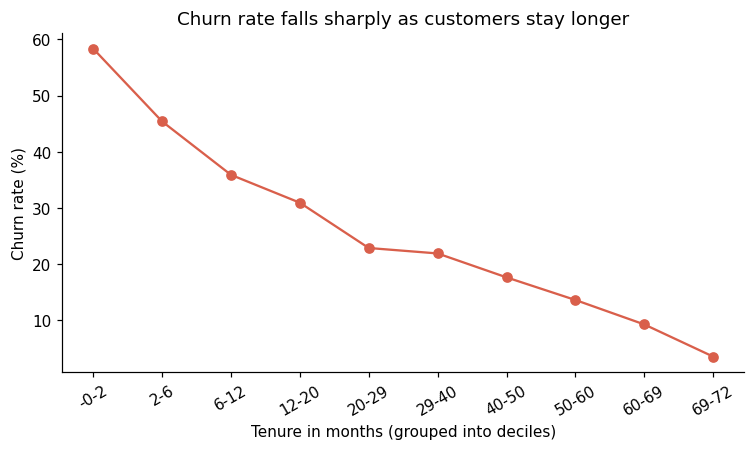

In [5]:
bins = pd.qcut(df["tenure"], 10, duplicates="drop")
rate = df.groupby(bins, observed=True)[TARGET].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(rate)), rate.values, marker="o", color=RED)
ax.set_xticks(range(len(rate)))
ax.set_xticklabels([f"{i.left:.0f}-{i.right:.0f}" for i in rate.index], rotation=30)
ax.set_xlabel("Tenure in months (grouped into deciles)")
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn rate falls sharply as customers stay longer")
plt.show()

## 3. Model comparison with cross-validation

I hold out 20% of customers as a **test set that is used only once, at the end**. Four models are compared with 5-fold cross-validation on the other 80%:

- logistic regression (simple, interpretable baseline)
- random forest
- gradient boosting with default settings
- gradient boosting with tuned hyperparameters (found with a 30-combination randomized search in `churn_tuning.py`)

In [6]:
y = df[TARGET]
X = df.drop(columns=[TARGET, ID_COL])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)


def make_pipeline(clf, scale=True):
    num = X.select_dtypes(include="number").columns.tolist()
    cat = X.select_dtypes(exclude="number").columns.tolist()
    num_steps = [("imp", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("sc", StandardScaler()))
    pre = ColumnTransformer([
        ("num", Pipeline(num_steps), num),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat),
    ])
    return Pipeline([("pre", pre), ("clf", clf)])


TUNED_PARAMS = dict(learning_rate=0.0636, max_depth=3, max_iter=121, max_leaf_nodes=8,
                    min_samples_leaf=58, l2_regularization=9.31, random_state=42)

models = {
    "Logistic regression": make_pipeline(LogisticRegression(max_iter=2000)),
    "Random forest": make_pipeline(RandomForestClassifier(
        n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=42)),
    "Gradient boosting (default)": make_pipeline(HistGradientBoostingClassifier(random_state=42)),
    "Gradient boosting (tuned)": make_pipeline(HistGradientBoostingClassifier(**TUNED_PARAMS)),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for name, pipe in models.items():
    res = cross_validate(pipe, X_train, y_train, cv=cv, n_jobs=-1, scoring="roc_auc")
    rows.append({"model": name, "cv_auc_mean": res["test_score"].mean(),
                 "cv_auc_std": res["test_score"].std()})
cv_table = pd.DataFrame(rows).round(3)
cv_table

,model,cv_auc_mean,cv_auc_std
0,Logistic regression,0.846,0.013
1,Random forest,0.845,0.009
2,Gradient boosting (default),0.838,0.007
3,Gradient boosting (tuned),0.850,0.011


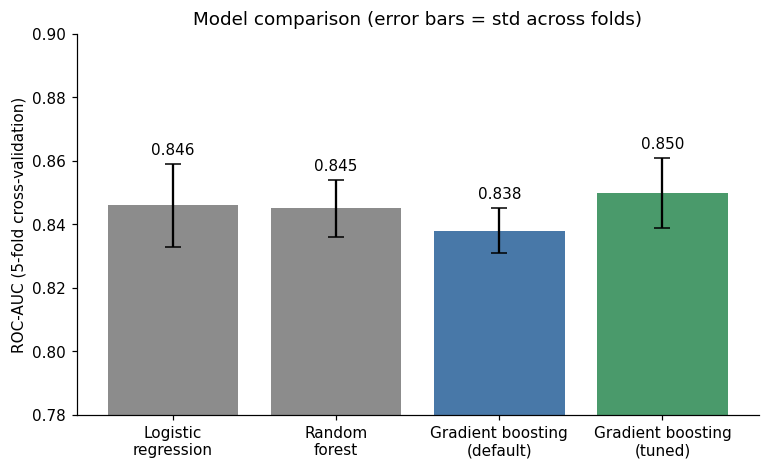

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
labels = [m.replace(" (", "\n(") if "(" in m else m.replace(" ", "\n", 1) for m in cv_table["model"]]
ax.bar(labels, cv_table["cv_auc_mean"], yerr=cv_table["cv_auc_std"],
       color=[GRAY, GRAY, BLUE, GREEN], capsize=5)
for i, (v, sd) in enumerate(zip(cv_table["cv_auc_mean"], cv_table["cv_auc_std"])):
    ax.text(i, v + sd + 0.003, f"{v:.3f}", ha="center")
ax.set_ylim(0.78, cv_table["cv_auc_mean"].max() + 0.05)
ax.set_ylabel("ROC-AUC (5-fold cross-validation)")
ax.set_title("Model comparison (error bars = std across folds)")
plt.show()

The tuned gradient boosting model scores highest, but the differences between the top models are **smaller than the fold-to-fold variation** (the error bars overlap). A plain logistic regression is nearly as good, which is common on this kind of tabular data. Now the one-time check on the untouched test set:

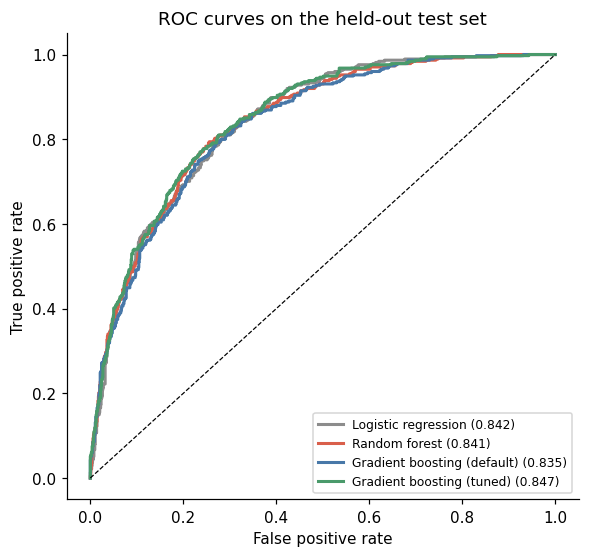

,model,ROC-AUC,PR-AUC,top-decile lift
0,Logistic regression,0.842,0.633,2.799
1,Random forest,0.841,0.648,2.906
2,Gradient boosting (default),0.835,0.645,2.879
3,Gradient boosting (tuned),0.847,0.660,2.852


In [8]:
def top_decile_lift(y_true, scores):
    d = pd.DataFrame({"y": np.asarray(y_true), "s": scores}).sort_values("s", ascending=False)
    return d.head(len(d) // 10).y.mean() / d.y.mean()


fitted, test_rows = {}, []
fig, ax = plt.subplots(figsize=(6, 5.5))
for (name, pipe), c in zip(models.items(), [GRAY, RED, BLUE, GREEN]):
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    p = pipe.predict_proba(X_test)[:, 1]
    test_rows.append({"model": name, "ROC-AUC": roc_auc_score(y_test, p),
                      "PR-AUC": average_precision_score(y_test, p),
                      "top-decile lift": top_decile_lift(y_test, p)})
    fpr, tpr, _ = roc_curve(y_test, p)
    ax.plot(fpr, tpr, color=c, lw=2, label=f"{name} ({roc_auc_score(y_test, p):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves on the held-out test set")
ax.legend(loc="lower right", fontsize=8)
plt.show()
pd.DataFrame(test_rows).round(3)

**Top-decile lift** answers a practical question: if the retention team can only contact the riskiest 10% of customers, how many more churners do they find than by picking at random? A lift near 2.8x means the model finds about 2.8 times as many.

## 4. What drives churn?

Two views: permutation importance (how much accuracy drops when a feature is shuffled) and SHAP values (how each feature pushes an individual customer's risk up or down).

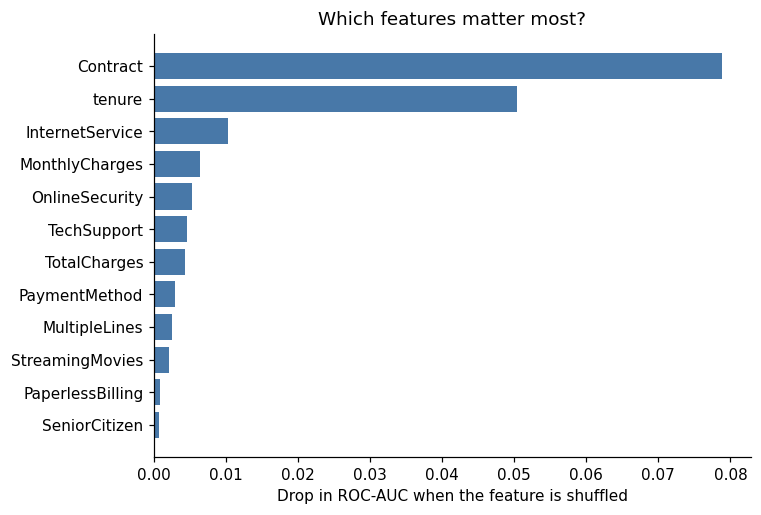

In [9]:
best = fitted["Gradient boosting (tuned)"]
imp = permutation_importance(best, X_test, y_test, scoring="roc_auc",
                             n_repeats=5, random_state=42)
ranked = pd.Series(imp.importances_mean, index=X_test.columns).sort_values().tail(12)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(ranked.index, ranked.values, color=BLUE)
ax.set_xlabel("Drop in ROC-AUC when the feature is shuffled")
ax.set_title("Which features matter most?")
plt.show()

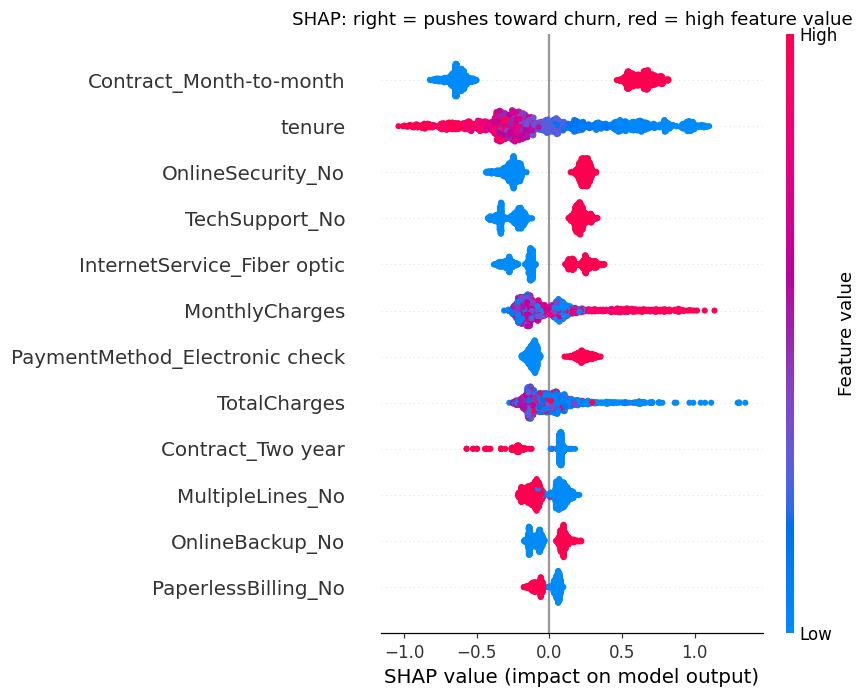

In [10]:
try:
    import shap

    # TreeExplainer supports scikit-learn's GradientBoostingClassifier
    pre = make_pipeline(None).named_steps["pre"].fit(X_train)
    Xtr, Xte = pre.transform(X_train), pre.transform(X_test)
    Xtr = Xtr.toarray() if hasattr(Xtr, "toarray") else Xtr
    Xte = Xte.toarray() if hasattr(Xte, "toarray") else Xte
    names = pre.get_feature_names_out()
    names = [n.split("__", 1)[-1] for n in names]

    gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                                    subsample=0.8, random_state=42).fit(Xtr, y_train)
    sv = shap.TreeExplainer(gb).shap_values(Xte)
    shap.summary_plot(sv, Xte, feature_names=names, show=False, max_display=12)
    plt.title("SHAP: right = pushes toward churn, red = high feature value")
    plt.show()
except ImportError:
    print("Install shap (pip install shap) to see the SHAP summary plot.")

The biggest drivers are **month-to-month contracts** (higher risk), **short tenure** (higher risk), and **missing online security or tech support** (higher risk). Customers on longer contracts with support services sit on the low-risk side.

These are associations found in the data, not proof of cause. For example, offering tech support to everyone would not necessarily cut churn by the amount the chart suggests.

## 5. Can we trust the probabilities? (calibration)

A churn *score* is only useful for money decisions if it behaves like a real probability: customers scored at 30% should churn about 30% of the time. I compare the model as-is with two standard fixes (sigmoid/Platt scaling and isotonic regression).

In [11]:
def expected_calibration_error(y_true, p, bins=10):
    idx = np.digitize(p, np.linspace(0, 1, bins + 1)[1:-1])
    return sum((idx == b).mean() * abs(y_true[idx == b].mean() - p[idx == b].mean())
               for b in range(bins) if (idx == b).any())


yt = y_test.to_numpy()
variants = {
    "Uncalibrated": fitted["Gradient boosting (tuned)"],
    "Sigmoid (Platt)": CalibratedClassifierCV(
        make_pipeline(HistGradientBoostingClassifier(**TUNED_PARAMS)),
        method="sigmoid", cv=5).fit(X_train, y_train),
    "Isotonic": CalibratedClassifierCV(
        make_pipeline(HistGradientBoostingClassifier(**TUNED_PARAMS)),
        method="isotonic", cv=5).fit(X_train, y_train),
}
probs = {k: m.predict_proba(X_test)[:, 1] for k, m in variants.items()}

pd.DataFrame([{"model": k, "ROC-AUC": roc_auc_score(yt, p), "Brier score": brier_score_loss(yt, p),
               "log loss": log_loss(yt, p), "calibration error": expected_calibration_error(yt, p)}
              for k, p in probs.items()]).round(4)

,model,ROC-AUC,Brier score,log loss,calibration error
0,Uncalibrated,0.8468,0.1352,0.4146,0.0218
1,Sigmoid (Platt),0.8483,0.1344,0.4129,0.0109
2,Isotonic,0.8479,0.1347,0.4136,0.0287


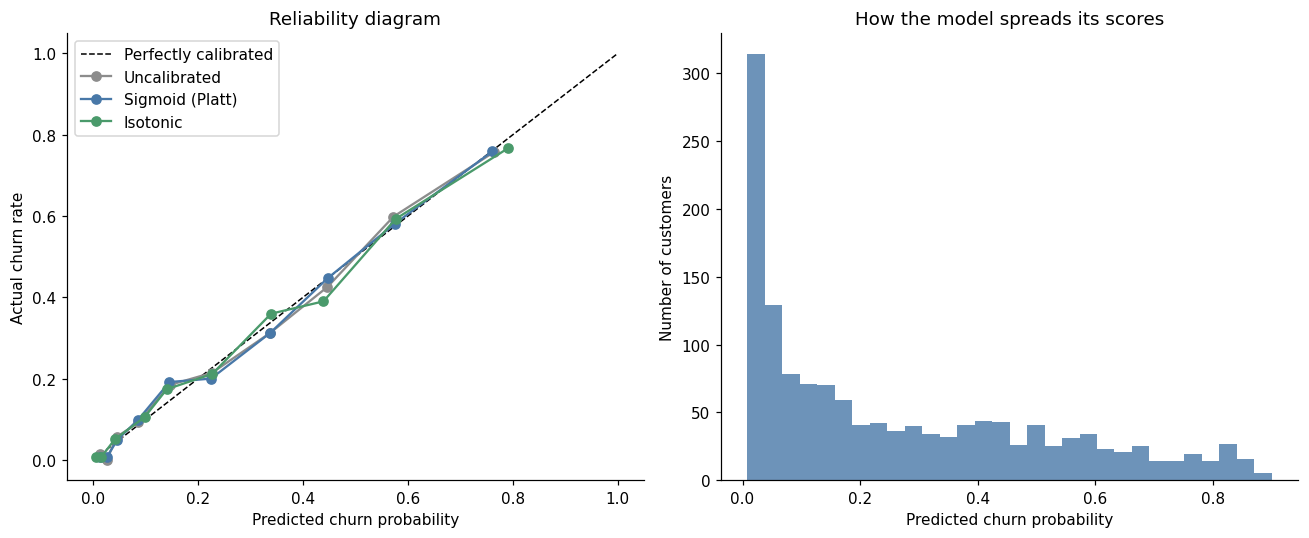

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot([0, 1], [0, 1], "k--", lw=1, label="Perfectly calibrated")
for (name, p), c in zip(probs.items(), [GRAY, BLUE, GREEN]):
    frac_pos, mean_pred = calibration_curve(yt, p, n_bins=10, strategy="quantile")
    ax1.plot(mean_pred, frac_pos, marker="o", color=c, label=name)
ax1.set_xlabel("Predicted churn probability")
ax1.set_ylabel("Actual churn rate")
ax1.set_title("Reliability diagram")
ax1.legend()
ax2.hist(probs["Uncalibrated"], bins=30, color=BLUE, alpha=0.8)
ax2.set_xlabel("Predicted churn probability")
ax2.set_ylabel("Number of customers")
ax2.set_title("How the model spreads its scores")
fig.tight_layout()
plt.show()

All three curves sit close to the diagonal, and every calibration error is small (roughly 0.01 to 0.03). Sigmoid scaling trims the error a little, isotonic regression is slightly worse, and the Brier scores barely move. **The model was already well calibrated**, so the raw scores can be used directly as probabilities in the money calculation below. (With only about 1,400 test customers, differences this small are within noise.)

## 6. Limitations of the split used here

The dataset has no dates, so I use a random split. In a real deployment the model would predict *future* churn from *past* behaviour, and should be tested on later time periods than it was trained on. Results on real data could be somewhat worse than shown here.

## 7. From predictions to money: who should we contact?

A model only matters if it changes a decision. Suppose we can offer at-risk customers a retention discount.

**Assumptions (illustrative, not real company data):**
- each retention offer costs **$50** (discount plus outreach)
- **30%** of contacted churners are actually saved
- a saved customer is worth **12 months** of their monthly charges at a **50% margin**

To avoid fooling myself, I split the data three ways: train the model on 60%, **choose the risk cutoff on a 20% validation set**, and report results on a separate 20% test set that played no part in choosing anything. (The model settings here match `churn_business_impact.py`, so the numbers agree with that script.)

In [13]:
COST, SUCCESS, HORIZON, MARGIN = 50.0, 0.30, 12, 0.5
value_all = df["MonthlyCharges"].fillna(df["MonthlyCharges"].median()) * HORIZON * MARGIN

X_tmp, X_te, y_tmp, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_tr, X_val, y_tr, y_val = train_test_split(X_tmp, y_tmp, test_size=0.25, stratify=y_tmp, random_state=42)

biz_model = make_pipeline(HistGradientBoostingClassifier(
    max_depth=4, learning_rate=0.05, max_iter=200, random_state=42), scale=False).fit(X_tr, y_tr)
s_val, s_te = biz_model.predict_proba(X_val)[:, 1], biz_model.predict_proba(X_te)[:, 1]
yv, yte = y_val.to_numpy(), y_te.to_numpy()
vv, vte = value_all.loc[X_val.index].to_numpy(), value_all.loc[X_te.index].to_numpy()


def net_curve(y_true, value, scores, cost, success):
    order = np.argsort(-scores)
    gain = success * np.cumsum(y_true[order] * value[order])
    spend = cost * np.arange(1, len(y_true) + 1)
    return np.concatenate([[0.0], gain - spend]), scores[order]


# choose the cutoff on the validation set only
net_v, sorted_v = net_curve(yv, vv, s_val, COST, SUCCESS)
k_opt = int(np.argmax(net_v))
threshold = sorted_v[k_opt - 1]

# evaluate on the test set
mask = s_te >= threshold
n, per_1000 = len(yte), 1000 / len(yte)
total_churn_value = (yte * vte).sum()
net_model = SUCCESS * (yte[mask] * vte[mask]).sum() - COST * mask.sum()
net_all = SUCCESS * total_churn_value - COST * n
frac = mask.mean()
net_random = frac * SUCCESS * total_churn_value - COST * mask.sum()

print(f"Cutoff chosen on validation data: risk score >= {threshold:.2f}")
print(f"Contacts {frac:.0%} of test customers, reaching {yte[mask].sum() / yte.sum():.0%} of all churners")
print(f"Precision of the contact list: {yte[mask].mean():.0%} (overall churn rate {yte.mean():.0%})")

Cutoff chosen on validation data: risk score >= 0.40
Contacts 29% of test customers, reaching 65% of all churners
Precision of the contact list: 59% (overall churn rate 27%)


Do nothing                      0
Contact everyone           -15233
Contact 29% at random       -4433
Contact top 29% by model     8754


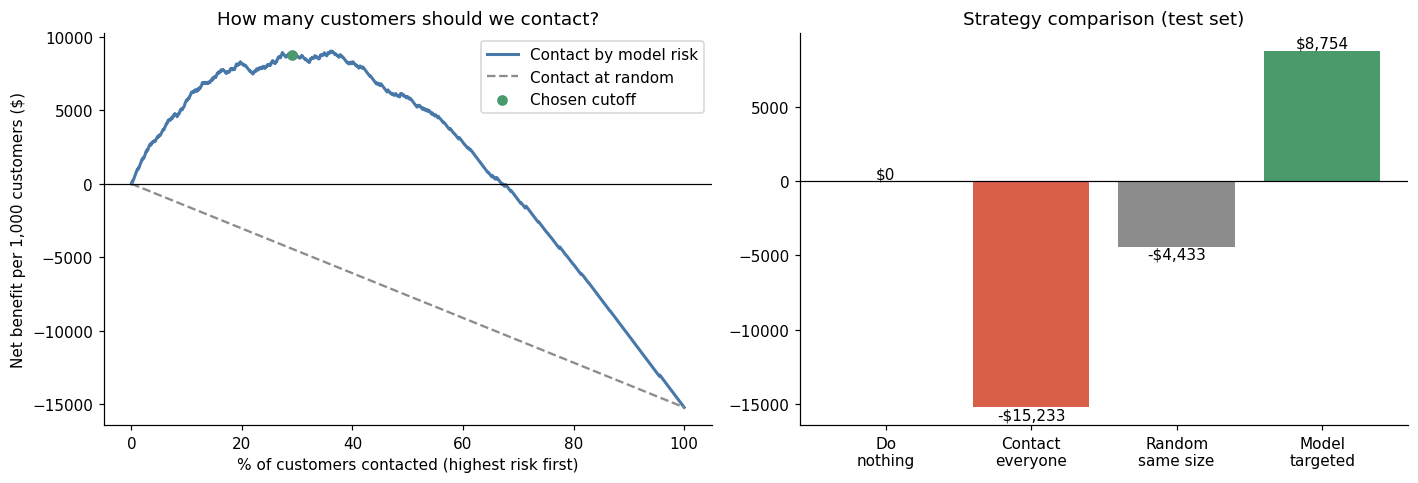

In [14]:
strategies = {"Do nothing": 0.0, "Contact everyone": net_all,
              f"Contact {frac:.0%} at random": net_random,
              f"Contact top {frac:.0%} by model": net_model}
result = pd.Series({k: round(v * per_1000) for k, v in strategies.items()},
                   name="Net benefit per 1,000 customers ($)")
print(result.to_string())

net_t, _ = net_curve(yte, vte, s_te, COST, SUCCESS)
x = np.arange(n + 1) / n
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(x * 100, net_t * per_1000, color=BLUE, lw=2, label="Contact by model risk")
ax1.plot(x * 100, x * net_all * per_1000, color=GRAY, ls="--", label="Contact at random")
ax1.scatter([frac * 100], [net_model * per_1000], color=GREEN, zorder=5, label="Chosen cutoff")
ax1.axhline(0, color="black", lw=0.8)
ax1.set_xlabel("% of customers contacted (highest risk first)")
ax1.set_ylabel("Net benefit per 1,000 customers ($)")
ax1.set_title("How many customers should we contact?")
ax1.legend()
vals = list(result.values)
bars = ax2.bar(range(4), vals, color=[GRAY, RED, GRAY, GREEN])
for b, v in zip(bars, vals):
    ax2.text(b.get_x() + b.get_width() / 2, v, f"${v:,.0f}" if v >= 0 else f"-${-v:,.0f}",
             ha="center", va="bottom" if v >= 0 else "top")
ax2.set_xticks(range(4))
ax2.set_xticklabels(["Do\nnothing", "Contact\neveryone", "Random\nsame size", "Model\ntargeted"])
ax2.axhline(0, color="black", lw=0.8)
ax2.set_title("Strategy comparison (test set)")
fig.tight_layout()
plt.show()

Under these assumptions, contacting everyone **loses money**, because most customers would not have left anyway and every offer costs $50. Contacting only the highest-risk customers is profitable. The profit curve is fairly flat around the optimum, so the result does not hinge on one exact cutoff.

**How sensitive is this to the assumptions?** The biggest unknown is the offer success rate:

In [15]:
rows = []
for s in [0.1, 0.2, 0.3, 0.4, 0.5]:
    nm = s * (yte[mask] * vte[mask]).sum() - COST * mask.sum()
    na = s * total_churn_value - COST * n
    rows.append({"offer success rate": f"{s:.0%}",
                 "model-targeted ($ per 1,000)": round(nm * per_1000),
                 "contact everyone ($ per 1,000)": round(na * per_1000)})
pd.DataFrame(rows)

,offer success rate,"model-targeted ($ per 1,000)","contact everyone ($ per 1,000)"
0,10%,-6782,-38411
1,20%,986,-26822
2,30%,8754,-15233
3,40%,16522,-3644
4,50%,24290,7945


If offers save only 10% of contacted churners, even model-targeted outreach loses money. This is why the success rate should be measured with a small randomized test in practice, not assumed.

## 8. Conclusions

- **Who churns:** customers on month-to-month contracts, with short tenure, fiber optic internet, and no online security or tech support.
- **Model:** a tuned gradient boosting model reaches about 0.85 ROC-AUC, but a simple logistic regression is nearly as good. The gain from complexity is small.
- **Trust:** predicted probabilities were already well calibrated, so they can drive dollar-based decisions directly.
- **Business value:** under the stated assumptions, targeting the top slice of customers by risk is profitable, while contacting everyone is not. The result depends heavily on the offer success rate.

**Limitations and next steps**
- Dollar figures rest on assumed costs and save rates, not real company data.
- Random rather than time-based split (the dataset has no dates).
- The data has no record of who received retention offers, so the model predicts who is *likely to churn*, not who would *respond to an offer*. Uplift modeling would need data from a randomized retention experiment.